In [ ]:
!pip install -q transformers datasets sentencepiece scikit-learn tqdm

In [1]:
!nvidia-smi

Sat Dec 27 15:25:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import torch.nn as nn
from transformers import XLNetModel
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from transformers import XLNetTokenizer
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
EVASION_TO_CLARITY = {
    "Explicit": "Clear Reply",
    "Implicit": "Ambivalent",
    "Dodging": "Ambivalent",
    "General": "Ambivalent",
    "Deflection": "Ambivalent",
    "Partial/half-answer": "Ambivalent",
    "Declining to answer": "Clear Non-Reply",
    "Claims ignorance": "Clear Non-Reply",
    "Clarification": "Clear Non-Reply"
}

CLARITY_LABEL = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

EVASION_LABELS = ["Explicit", "Implicit", "Dodging", "General", "Deflection", "Partial/half-answer", "Declining to answer", "Claims ignorance", "Clarification"]

In [4]:
# Direct XLNet Model
class DirectClarityXLNet(nn.Module):
    def __init__(self, num_labels = 3):
        super().__init__()
        self.xlnet = XLNetModel.from_pretrained("xlnet-base-cased")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.xlnet.config.d_model, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.xlnet(input_ids = input_ids, attention_mask=attention_mask)

        cls_output = outputs.last_hidden_state[:, -1, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

In [5]:
# Hierarchical XLNet Model
class EvasionClarityXLNet(nn.Module):
    def __init__(self, num_labels = 9):
        super().__init__()
        self.xlnet = XLNetModel.from_pretrained("xlnet-base-cased")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.xlnet.config.d_model, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.xlnet(input_ids = input_ids, attention_mask=attention_mask)

        cls_output = outputs.last_hidden_state[:, -1, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

In [6]:
class QEDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length = 512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation = True,
            padding = "max_length",
            max_length = self.max_length,
            return_tensors = "pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

*Load Dataset*

In [7]:
def load_data():
    # Load dataset
    dataset = load_dataset("ailsntua/QEvasion")

    train_df = dataset["train"].to_pandas()
    test_df = dataset["test"].to_pandas()

    # Just keep relevant information
    cols = ["interview_question", "interview_answer", "clarity_label", "evasion_label"]
    train_df = train_df[cols].dropna(subset=["interview_question", "interview_answer", "clarity_label", "evasion_label"])
    test_df = test_df[cols].dropna(subset=["interview_question", "interview_answer", "clarity_label"])

    # Mapping
    clarity2id = {label: i for i, label in enumerate(CLARITY_LABEL)}
    evasion2id = {label: i for i, label in enumerate(EVASION_LABELS)}

    train_df["clarity_id"] = train_df["clarity_label"].map(clarity2id)
    train_df["evasion_id"] = train_df["evasion_label"].map(evasion2id)

    test_df["clarity_id"] = test_df["clarity_label"].map(clarity2id)

    return train_df, test_df, clarity2id, evasion2id

In [8]:
def combine_question_answer(question, answer):
    q = str(question).strip() if pd.notna(question) else ""
    a = str(answer).strip() if pd.notna(answer) else ""
    return f"Question: {q} Answer: {a}"

In [9]:
# Train and evaluate normal model
def train_direct(combine_q_a = False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load data
    train_df, test_df, clarity2id, _ = load_data()

    text_data_train = train_df["interview_answer"]
    text_data_test = test_df["interview_answer"]

    if combine_q_a:
        train_df["input_text"] = train_df.apply(
            lambda row: combine_question_answer(row["interview_question"], row["interview_answer"]), axis=1
        )
        test_df["input_text"] = test_df.apply(
            lambda row: combine_question_answer(row["interview_question"], row["interview_answer"]), axis=1
        )

        text_data_train = train_df["input_text"]
        text_data_test = test_df["input_text"]

    tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

    # Train Dataset
    train_dataset = QEDataset(
        texts=text_data_train.to_list(),
        labels=train_df["clarity_id"].to_list(),
        tokenizer=tokenizer
    )

    test_dataset = QEDataset(
        texts=text_data_test.to_list(),
        labels = test_df["clarity_id"].to_list(),
        tokenizer=tokenizer
    )

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    # Model
    model = DirectClarityXLNet(num_labels=3).to(device=device)
    optimizer = torch.optim.AdamW(model.parameters(), lr = 2e-5)

    labels = train_df["clarity_id"].values
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

    # Training
    model.train()
    print("Training start")
    for epoch in range(15):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        print(f"Epoch {epoch + 1} Loss: {total_loss / len(train_loader):.4f}")


    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n=== Classification Report (Per-Class) ===")
    print(classification_report(all_labels, all_preds, target_names=CLARITY_LABEL, digits=4))

    # Confusionmatrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLARITY_LABEL, yticklabels=CLARITY_LABEL)
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig("confusion_matrix_direct.png", dpi=150)
    plt.show()

    torch.save(model.state_dict(), "xlnet_direct_clarity.pth")

In [10]:
# Train Hirarchical
def train_evasion(combine_q_a = False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_df, _, _, evasion2id = load_data()


    text_data_train = train_df["interview_answer"]

    if combine_q_a:
        train_df["input_text"] = train_df.apply(
            lambda row: combine_question_answer(row["interview_question"], row["interview_answer"]), axis=1
        )

        text_data_train = train_df["input_text"]

    tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

    train_dataset = QEDataset(
        texts = text_data_train.to_list(),
        labels = train_df["evasion_id"].to_list(),
        tokenizer = tokenizer
    )


    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

    labels = train_df["evasion_id"].values
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    model = EvasionClarityXLNet(num_labels=9).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

    model.train()
    for epoch in range(15):

        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Evasion Epoch {epoch + 1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss / len(train_loader):.4f}")

    torch.save(model.state_dict(), "xlnet_evasion.pth")
    print("Evasion model saved to xlnet_evasion.pth")





In [11]:
# Evaluate Hirarchical training
def evaluate_hir(combine_q_a = False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    clarity2id = {label: i for i, label in enumerate(CLARITY_LABEL)}
    evasion_id_to_clarity = []
    for evasion_label in EVASION_LABELS:
        clarity_label = EVASION_TO_CLARITY[evasion_label]
        evasion_id_to_clarity.append(clarity2id[clarity_label])

    _, test_df, _, _ = load_data()

    text_data_train = test_df["interview_answer"]

    if combine_q_a:
        test_df["input_text"] = test_df.apply(
            lambda row: combine_question_answer(row["interview_question"], row["interview_answer"]), axis=1
        )

        text_data_train = test_df["input_text"]

    tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

    test_dataset = QEDataset(
        texts = text_data_train.to_list(),
        labels = test_df["clarity_id"].to_list(),
        tokenizer = tokenizer
    )

    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    model = EvasionClarityXLNet(num_labels=9).to(device)
    model.load_state_dict(torch.load("xlnet_evasion.pth", map_location=device))
    model.eval()

    all_clarity_preds = []
    all_clarity_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Hierarchical Evaluation"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            true_clarity_label = batch["labels"].cpu().numpy()

            evasion_logits = model(input_ids, attention_mask)
            evasion_preds = torch.argmax(evasion_logits, dim=1).cpu().numpy()

            clarity_preds = [evasion_id_to_clarity[evasion_id] for evasion_id in evasion_preds]

            all_clarity_preds.extend(clarity_preds)
            all_clarity_labels.extend(true_clarity_label)

    print("\n=== Hierarchical Model (Per-Class) ===")
    print(classification_report(all_clarity_labels, all_clarity_preds, target_names=CLARITY_LABEL, digits=4))

    # ⭐ Konfusionsmatrix
    cm = confusion_matrix(all_clarity_labels, all_clarity_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=CLARITY_LABEL, yticklabels=CLARITY_LABEL)
    plt.title("Confusion Matrix (Hierarchical)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig("confusion_matrix_hierarchical.png", dpi=150)
    plt.show()

    macro_f1 = f1_score(all_clarity_labels, all_clarity_preds, average="macro")
    micro_f1 = f1_score(all_clarity_labels, all_clarity_preds, average="micro")
    acc = accuracy_score(all_clarity_labels, all_clarity_preds)

    print("=== Hierarchical (Evasion -> Clarity) Results ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Micro F1: {micro_f1:.4f}")

    return {"accuracy": acc, "macro_f1": macro_f1, "micro_f1": micro_f1}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

...

Epoch 13 Loss: 0.3970


Epoch 14: 100%|██████████| 431/431 [07:25<00:00,  1.03s/it]


Epoch 14 Loss: 0.3801


Epoch 15: 100%|██████████| 431/431 [07:25<00:00,  1.03s/it]


Epoch 15 Loss: 0.3535

=== Classification Report (Per-Class) ===
                 precision    recall  f1-score   support

    Clear Reply     0.3276    0.4810    0.3897        79
     Ambivalent     0.7609    0.5097    0.6105       206
Clear Non-Reply     0.3519    0.8261    0.4935        23

       accuracy                         0.5260       308
      macro avg     0.4801    0.6056    0.4979       308
   weighted avg     0.6192    0.5260    0.5451       308



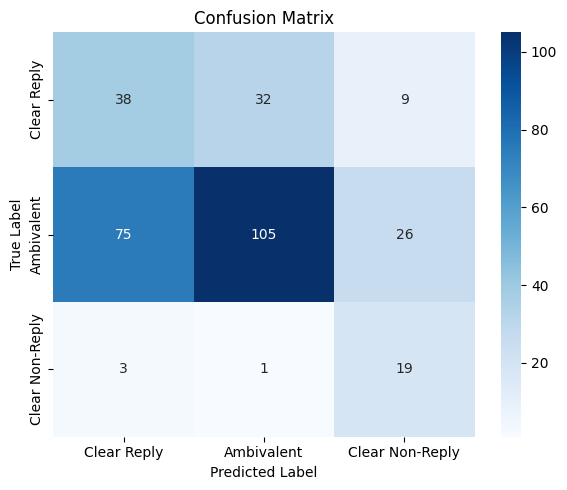

In [ ]:
train_direct(combine_q_a=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

...

Epoch 14 Loss: 0.6969


Evasion Epoch 15: 100%|██████████| 431/431 [07:15<00:00,  1.01s/it]


Epoch 15 Loss: 0.6960
Evasion model saved to xlnet_evasion.pth


Hierarchical Evaluation: 100%|██████████| 39/39 [00:14<00:00,  2.62it/s]



=== Hierarchical Model (Per-Class) ===
                 precision    recall  f1-score   support

    Clear Reply     0.3731    0.3165    0.3425        79
     Ambivalent     0.7208    0.6893    0.7047       206
Clear Non-Reply     0.3182    0.6087    0.4179        23

       accuracy                         0.5877       308
      macro avg     0.4707    0.5382    0.4884       308
   weighted avg     0.6016    0.5877    0.5904       308



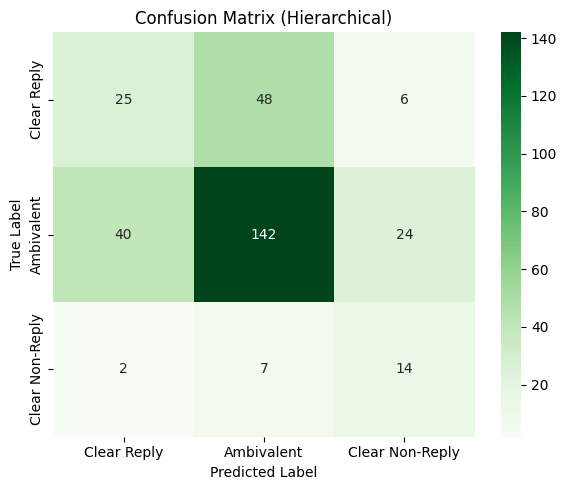

=== Hierarchical (Evasion -> Clarity) Results ===
Accuracy: 0.5877
Macro F1: 0.4884
Micro F1: 0.5877


{'accuracy': 0.5876623376623377,
 'macro_f1': 0.48836361379478754,
 'micro_f1': 0.5876623376623377}

In [12]:
train_evasion(combine_q_a=False)
evaluate_hir(combine_q_a=False)

In [ ]:
train_direct(combine_q_a=True)

In [ ]:
train_evasion(combine_q_a=True)
evaluate_hir(combine_q_a=True)